# Issue #6 — Apparel CPI vs. Wages

Live FRED pull: `CPIAPPSL` (apparel CPI) vs. `AHETPI` (average hourly earnings).

Purpose: establish whether apparel affordability, in aggregate, has improved or gotten worse over the decades. This sets up honest context for the issue, not a predetermined conclusion, the ending copy gets written after examining what this actually displays.

**Known risk:** apparel CPI has historically stayed flat or declined relative to overall inflation, largely due to fast fashion. If th`at's what shows up here, it doesn't kill the issue, it sharpens it: the *baseline* garment got cheaper, but the *status* garment didn't move the same way.

## 1. Setup

In [25]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("FRED_API_KEY")

if not API_KEY:
    raise ValueError("FRED_API_KEY not found. Check the .env file.")

### 1.1 Fetch helper

FRED returns a JSON error object rather than an HTTP error on bad requests, so `resp.json()` gets printed before raising to actually see what FRED says went wrong.

In [26]:
def fetch_fred_series(series_id, start_date="1960-01-01"):
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "observation_start": start_date,
    }
    resp = requests.get(url, params=params)
    data = resp.json()

    if "observations" not in data:
        print(data)  # surface FRED's actual error before debugging further
        raise KeyError(f"'observations' not in response for series {series_id}")

    df = pd.DataFrame(data["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df[["date", "value"]].dropna().set_index("date")


## 2. Load brand palette

In [27]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.facecolor"] = COCOA
plt.rcParams["figure.facecolor"] = COCOA
plt.rcParams["text.color"] = CREAM
plt.rcParams["axes.labelcolor"] = CREAM
plt.rcParams["xtick.color"] = CREAM
plt.rcParams["ytick.color"] = CREAM

## 2. Extracting data

### 2.1 Pull both series

In [28]:
apparel_cpi = fetch_fred_series("CPIAPPSL")
wages = fetch_fred_series("AHETPI")

print(f"Apparel CPI: {len(apparel_cpi)} observations, {apparel_cpi.index.min().date()} to {apparel_cpi.index.max().date()}")
print(f"Wages: {len(wages)} observations, {wages.index.min().date()} to {wages.index.max().date()}")

Apparel CPI: 798 observations, 1960-01-01 to 2026-07-01
Wages: 751 observations, 1964-01-01 to 2026-07-01


In [29]:
# save the data into the data folder
raw_dir = "../../data/raw/issue-06-coat-of-many-colors"
os.makedirs(raw_dir, exist_ok=True)

apparel_cpi.to_csv(f"{raw_dir}/apparel_cpi_raw.csv")
wages.to_csv(f"{raw_dir}/wages_raw.csv")

print(f"Saved raw pulls to {raw_dir}/")

Saved raw pulls to ../../data/raw/issue-06-coat-of-many-colors/


### 2.2 Align and index to common base year

Both series need to start from the same reference point (100) so they're comparable on the same scale regardless of their raw units. Using the earliest year both series share as the base.

In [30]:
# resample both to monthly, align on shared date range
apparel_monthly = apparel_cpi.resample("MS").mean()
wages_monthly = wages.resample("MS").mean()

combined = pd.DataFrame({
    "apparel_cpi": apparel_monthly["value"],
    "wages": wages_monthly["value"],
}).dropna()

# index both to 100 at the first shared date
base = combined.iloc[0]
indexed = combined / base * 100

print(f"Base year: {indexed.index[0].date()}")
indexed.tail()


Base year: 1964-01-01


,apparel_cpi,wages
date,,
2026-03-01,287.720339,1284.8
2026-04-01,289.555085,1289.2
2026-05-01,290.400424,1292.4
2026-06-01,288.798729,1294.4
2026-07-01,289.055085,1296.0


In [31]:
# save the data to the processed data folder
processed_dir = "../../data/processed/issue-06-coat-of-many-colors"
os.makedirs(processed_dir, exist_ok=True)

indexed.to_csv(f"{processed_dir}/apparel_cpi_vs_wages_indexed.csv")

print(f"Saved processed/indexed data to {processed_dir}/")

Saved processed/indexed data to ../../data/processed/issue-06-coat-of-many-colors/


### 2.4 Data for chart 6.1 in Canva

In [36]:
# Pull yearly sample points for manual entry into Canva
yearly = indexed.resample("YS").first()  # one value per year, taken from January
yearly.index = yearly.index.year  # cleaner labels, just the year number

print(yearly.round(0).to_string())

      apparel_cpi   wages
date                     
1964        100.0   100.0
1965        101.0   103.0
1966        102.0   107.0
1967        106.0   112.0
1968        110.0   118.0
1969        118.0   125.0
1970        123.0   132.0
1971        128.0   141.0
1972        131.0   152.0
1973        134.0   161.0
1974        140.0   171.0
1975        152.0   184.0
1976        156.0   196.0
1977        164.0   210.0
1978        170.0   226.0
1979        176.0   245.0
1980        187.0   263.0
1981        198.0   287.0
1982        205.0   309.0
1983        209.0   322.0
1984        215.0   335.0
1985        219.0   344.0
1986        225.0   354.0
1987        229.0   361.0
1988        240.0   372.0
1989        251.0   386.0
1990        254.0   401.0
1991        269.0   415.0
1992        277.0   426.0
1993        281.0   437.0
1994        282.0   448.0
1995        280.0   459.0
1996        281.0   474.0
1997        280.0   492.0
1998        282.0   512.0
1999        279.0   531.0
2000        

In [37]:
# Every 5 years instead of every year, more Canva-friendly
yearly_sparse = yearly.iloc[::5]
print(yearly_sparse.round(0).to_string())

      apparel_cpi   wages
date                     
1964        100.0   100.0
1969        118.0   125.0
1974        140.0   171.0
1979        176.0   245.0
1984        215.0   335.0
1989        251.0   386.0
1994        282.0   448.0
1999        279.0   531.0
2004        254.0   620.0
2009        250.0   736.0
2014        271.0   816.0
2019        264.0   925.0
2024        275.0  1184.0


In [44]:
canva_export = yearly_sparse.copy()
canva_export.loc[2026] = indexed.iloc[-1]  # add the 2026 endpoint
canva_export.index.name = "date"

canva_export.to_csv("../../data/processed/issue-06-coat-of-many-colors/06a-canva-chart-data.csv")
print(canva_export)

      apparel_cpi   wages
date                     
1964   100.000000   100.0
1969   117.584746   124.8
1974   140.466102   170.8
1979   175.847458   245.2
1984   215.042373   335.2
1989   250.847458   386.0
1994   282.415254   448.0
1999   278.601695   530.8
2004   254.449153   620.4
2009   249.930085   735.6
2014   270.936441   815.6
2019   263.699153   925.2
2024   274.756356  1184.4
2026   289.055085  1296.0


## 3. Plot

A raw matplotlib is used, without styling, this is the exploratory chart to see the actual shape. Final Canva-styled version gets built separately once the shape and ending copy are locked. Chart palette for this cycle (Issues #6-10): Dusty pink background with Cream accents, applied in Canva, not baked into this export.

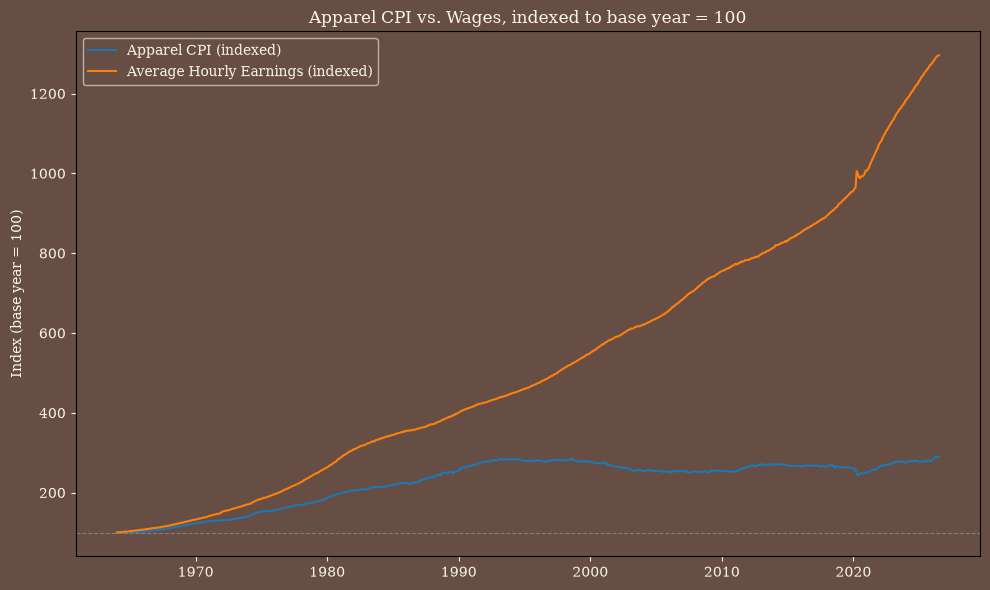

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(indexed.index, indexed["apparel_cpi"], label="Apparel CPI (indexed)")
ax.plot(indexed.index, indexed["wages"], label="Average Hourly Earnings (indexed)")
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Apparel CPI vs. Wages, indexed to base year = 100")
ax.set_ylabel("Index (base year = 100)")
ax.legend()
plt.tight_layout()
plt.show()

# once this shape looks right, export clean (no annotations) for canva:
fig.savefig("../../sources/issue-06/6.1-apparel-cpi-vs-wages-raw.png", dpi=300, transparent=False)

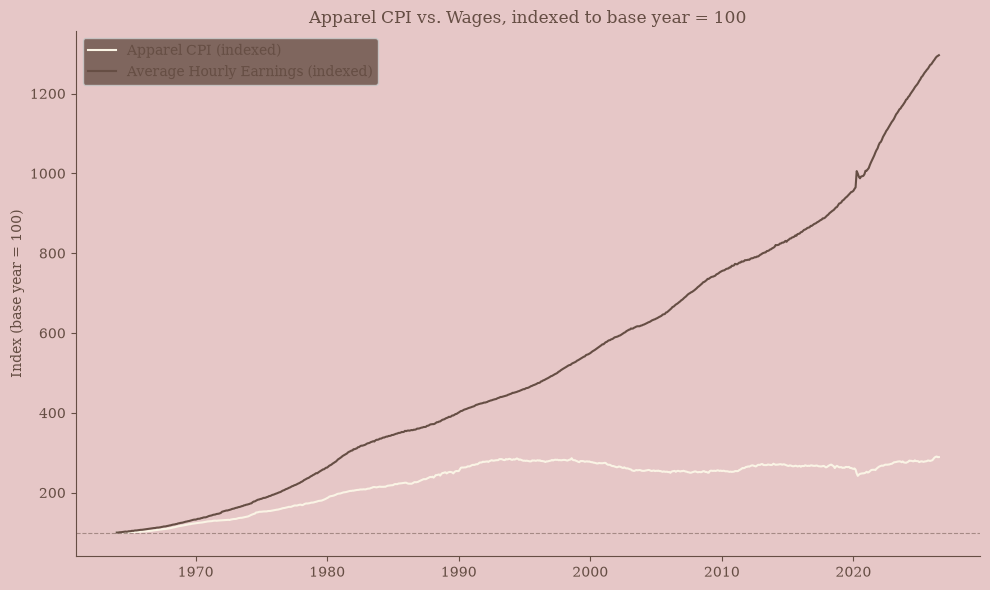

In [35]:
# branded version, separate figure so the exploratory chart above stays untouched
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(indexed.index, indexed["apparel_cpi"], label="Apparel CPI (indexed)", color=CREAM)
ax2.plot(indexed.index, indexed["wages"], label="Average Hourly Earnings (indexed)", color=COCOA)
ax2.axhline(100, color=COCOA, linestyle="--", linewidth=0.8, alpha=0.5)

fig2.patch.set_facecolor(DUSTY)
ax2.set_facecolor(DUSTY)
ax2.set_title("Apparel CPI vs. Wages, indexed to base year = 100", color=COCOA)
ax2.set_ylabel("Index (base year = 100)", color=COCOA)
ax2.tick_params(colors=COCOA)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color(COCOA)
ax2.spines["bottom"].set_color(COCOA)
leg = ax2.legend()
for text in leg.get_texts():
    text.set_color(COCOA)

plt.tight_layout()
plt.show()

fig2.savefig("../../content/posts/issue-06-coat-of-many-colors/exports/6.1a-apparel-cpi-vs-wages-raw.png", dpi=300, transparent=False)

## 4. Findings

Apparel CPI stayed nearly flat, rising from an indexed 100 to roughly 290 since the base year. Average hourly earnings rose to roughly 1,300 over the same period. Clothes did not get more expensive relative to income, they got dramatically cheaper. The piece reframes around this: it's not that clothes are unaffordable, it's that the specific "safe" brands that spare a kid from being singled out didn't get cheap at anywhere near that rate.